<a href="https://colab.research.google.com/github/StevensRemache/MODELAMIENTO_Y_SIMULACION_REMACHE_VALERIA/blob/main/REMACHE_VALERIA_Simulacion_Sistemas_Datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Instalación de SimPy**

In [9]:
# ============================================
# Agrego esta celda para instalar la librería SimPy,
# que es necesaria para realizar la simulación de eventos discretos.
# SimPy nos permite modelar sistemas de colas y procesamiento
# de manera eficiente y con un enfoque orientado a eventos.
# ============================================

!pip install simpy

**Importación de Librerías**

In [10]:
# ============================================
# Importo las librerías necesarias para la simulación:
# - simpy: para la simulación de eventos discretos
# - random: para generar distribuciones estadísticas
# - numpy: para cálculos numéricos y estadísticos
# - matplotlib: para visualización de resultados
# Fijo la semilla aleatoria para garantizar reproducibilidad
# de los resultados en cada ejecución.
# ============================================

import simpy
import random
import numpy as np
import matplotlib.pyplot as plt

# Fijar semilla para reproducibilidad
random.seed(30)
np.random.seed(30)

# Configurar estilo de gráficos
plt.style.use('ggplot')

**Configuración de Parámetros Iniciales**

In [11]:
# ============================================
# Defino los parámetros de la arquitectura del sistema.
# Para el escenario de alta concurrencia (día de matrículas),
# incremento TASA_LLEGADA_DATOS a 80.0 peticiones por segundo.
# Con 1 servidor, esto provocará un colapso del sistema
# porque la tasa de llegada supera la capacidad de procesamiento.
# ============================================

# Flujo y Procesamiento (Peticiones por segundo)
TASA_LLEGADA_DATOS = 80.0      # Escenario de alta concurrencia
CAPACIDAD_PROCESAMIENTO = 60.0 # Procesamiento por servidor
NUM_SERVIDORES = 1             # Inicialmente 1 servidor (colapsará)

# Latencia de Red
LATENCIA_RED_MEDIA = 0.05      # 50ms de latencia de red

TIEMPO_SIMULACION = 60         # Simularemos 60 segundos

**Definición de la Clase SistemaDatos**

In [12]:
# ============================================
# Esta clase modela el sistema de procesamiento de datos.
# Agrego atributos adicionales para almacenar más métricas
# que permitan una mejor validación del modelo:
# - tiempos_llegada: momento de llegada de cada petición
# - tiempos_fin: momento de finalización de cada petición
# Estas métricas adicionales me permitirán calcular:
#   * Tiempo total en el sistema (Ley de Little)
#   * Distribución de tiempos de espera
#   * Percentiles de latencia
# ============================================

class SistemaDatos:
    def __init__(self, env, num_servidores, latencia_red):
        self.env = env
        self.servidores = simpy.Resource(env, capacity=num_servidores)
        self.latencia_red = latencia_red

        # Arreglos para telemetría y gráficos
        self.tiempos_respuesta_total = []
        self.tiempos_espera_cola = []
        self.marcas_tiempo = []

        # Métricas adicionales para validación funcional
        self.tiempos_llegada = []
        self.tiempos_fin = []

    def procesar_paquete(self, paquete_id, tasa_procesamiento):
        # Registro el momento de llegada de la petición
        tiempo_llegada = self.env.now
        self.tiempos_llegada.append(tiempo_llegada)

        # 1. LATENCIA: Viaje del paquete de datos por la red
        # La latencia de red sigue una distribución normal
        # con media LATENCIA_RED_MEDIA y desviación 0.01
        latencia_viaje = max(0.01, random.normalvariate(self.latencia_red, 0.01))
        yield self.env.timeout(latencia_viaje)

        llegada_al_servidor = self.env.now

        # 2. PROCESAMIENTO: Cola y uso de CPU
        with self.servidores.request() as peticion:
            yield peticion  # Espera en cola si el servidor está saturado

            # Calculo el tiempo de espera en cola
            tiempo_espera = self.env.now - llegada_al_servidor
            self.tiempos_espera_cola.append(tiempo_espera)

            # El tiempo de procesamiento sigue una distribución exponencial
            # con media 1/tasa_procesamiento
            tiempo_cpu = random.expovariate(tasa_procesamiento)
            yield self.env.timeout(tiempo_cpu)

        # 3. Métrica Final: Latencia End-to-End
        tiempo_total = self.env.now - tiempo_llegada
        self.tiempos_respuesta_total.append(tiempo_total)
        self.marcas_tiempo.append(self.env.now)
        self.tiempos_fin.append(self.env.now)

**Definición del Generador de Tráfico**

In [13]:
# ============================================
# Esta función genera el flujo de peticiones entrantes.
# El tiempo entre llegadas sigue una distribución exponencial
# con media 1/tasa_llegada, lo que modela adecuadamente
# el comportamiento de llegadas aleatorias en sistemas reales.
# ============================================

def generador_trafico(env, sistema, tasa_llegada, tasa_procesamiento):
    """Simula el flujo entrante constante de datos hacia el sistema"""
    paquete_id = 0
    while True:
        # El tiempo entre peticiones sigue distribución exponencial
        tiempo_entre_peticiones = random.expovariate(tasa_llegada)
        yield env.timeout(tiempo_entre_peticiones)

        paquete_id += 1
        env.process(sistema.procesar_paquete(paquete_id, tasa_procesamiento))

**Función para Simular el Sistema**

In [14]:
# ============================================
# Esta función ejecuta la simulación para un número dado de servidores.
# Retorna el objeto SistemaDatos con todas las métricas recolectadas.
# La modularidad me permite ejecutar múltiples simulaciones
# con diferentes configuraciones de servidores fácilmente.
# ============================================

def simular_sistema(num_servidores):
    """Ejecuta la simulación con N servidores y retorna el sistema"""
    env = simpy.Environment()
    sistema = SistemaDatos(env, num_servidores, LATENCIA_RED_MEDIA)

    env.process(generador_trafico(env, sistema, TASA_LLEGADA_DATOS, CAPACIDAD_PROCESAMIENTO))
    env.run(until=TIEMPO_SIMULACION)

    return sistema

**Función para Calcular y Mostrar Métricas**

In [15]:
# ============================================
# Esta función calcula todas las métricas relevantes del sistema:
# - Latencia promedio, máxima y percentiles
# - Tiempo de espera en cola
# - Factor de utilización (ρ)
# - Número promedio de peticiones en el sistema (Ley de Little)
# Estas métricas son fundamentales para la validación funcional
# del modelo y para justificar las decisiones de escalamiento.
# ============================================

def calcular_metricas(sistema, num_servidores):
    """Calcula y muestra todas las métricas del sistema"""

    # Métricas básicas
    latencia_media_ms = np.mean(sistema.tiempos_respuesta_total) * 1000
    espera_media_ms = np.mean(sistema.tiempos_espera_cola) * 1000
    latencia_max_ms = np.max(sistema.tiempos_respuesta_total) * 1000
    espera_max_ms = np.max(sistema.tiempos_espera_cola) * 1000
    latencia_std_ms = np.std(sistema.tiempos_respuesta_total) * 1000

    # Factor de utilización (Teoría de Colas)
    tasa_llegada = TASA_LLEGADA_DATOS
    tasa_servicio = CAPACIDAD_PROCESAMIENTO * num_servidores
    utilizacion = tasa_llegada / tasa_servicio if tasa_servicio > 0 else 0

    # Percentiles para análisis de colas
    percentil_95 = np.percentile(sistema.tiempos_respuesta_total, 95) * 1000
    percentil_99 = np.percentile(sistema.tiempos_respuesta_total, 99) * 1000

    # Ley de Little: L = λ * W
    # Donde L es el número promedio de peticiones en el sistema
    # λ es la tasa de llegada y W es el tiempo promedio en el sistema
    W = np.mean(sistema.tiempos_respuesta_total)
    L = TASA_LLEGADA_DATOS * W

    print(f"\n{'='*60}")
    print(f"SISTEMA CON {num_servidores} SERVIDOR(ES)")
    print(f"{'='*60}")
    print(f"Total de peticiones procesadas: {len(sistema.tiempos_respuesta_total)}")
    print(f"Latencia promedio: {latencia_media_ms:.2f} ms")
    print(f"Latencia máxima: {latencia_max_ms:.2f} ms")
    print(f"Desviación estándar latencia: {latencia_std_ms:.2f} ms")
    print(f"Percentil 95: {percentil_95:.2f} ms")
    print(f"Percentil 99: {percentil_99:.2f} ms")
    print(f"Tiempo de espera promedio en cola: {espera_media_ms:.2f} ms")
    print(f"Tiempo máximo de espera en cola: {espera_max_ms:.2f} ms")
    print(f"Factor de Utilización (ρ): {utilizacion:.2%}")
    print(f"Peticiones promedio en sistema (Ley de Little): {L:.2f}")

    # Evaluación del estado del sistema con emojis
    if utilizacion > 1:
        estado = "🔴 COLAPSADO - La cola crece infinitamente"
        color = "red"
    elif utilizacion > 0.8:
        estado = "🟡 SOBRECARGADO - Cercano al límite de estabilidad"
        color = "orange"
    elif utilizacion > 0.5:
        estado = "🟢 ESTABLE - Buen rendimiento"
        color = "green"
    else:
        estado = "🔵 INFRUTILIZADO - Capacidad excedente"
        color = "blue"

    print(f"Estado del sistema: {estado}")
    print(f"{'='*60}\n")

    return {
        'latencia_media_ms': latencia_media_ms,
        'espera_media_ms': espera_media_ms,
        'utilizacion': utilizacion,
        'estado': estado,
        'paquetes': len(sistema.tiempos_respuesta_total),
        'L': L
    }

**Función para Graficar Resultados**

In [16]:
# ============================================
# Esta función genera el gráfico de dispersión de latencias
# con línea de tendencia y promedio.
# La línea de tendencia me permite visualizar si la latencia
# está creciendo en el tiempo (sistema inestable) o
# se mantiene estable (sistema en estado estacionario).
# ============================================

def graficar_resultados(sistema, num_servidores):
    """Genera el gráfico de latencia con análisis de tendencia"""
    plt.figure(figsize=(12, 6))

    # Convertir tiempos a milisegundos para mejor visualización
    tiempos_ms = [t * 1000 for t in sistema.tiempos_respuesta_total]

    # Gráfico de dispersión
    plt.scatter(sistema.marcas_tiempo, tiempos_ms, alpha=0.5, s=10, color='royalblue')

    # Línea de promedio
    latencia_media_ms = np.mean(tiempos_ms)
    plt.axhline(y=latencia_media_ms, color='crimson', linestyle='--',
                linewidth=2, label=f'Promedio: {latencia_media_ms:.1f} ms')

    # Línea de tendencia (regresión lineal)
    if len(sistema.marcas_tiempo) > 1:
        z = np.polyfit(sistema.marcas_tiempo, tiempos_ms, 1)
        p = np.poly1d(z)
        x_trend = np.linspace(min(sistema.marcas_tiempo), max(sistema.marcas_tiempo), 100)
        plt.plot(x_trend, p(x_trend), color='darkgreen', linewidth=2,
                label=f'Tendencia: {z[0]:.1f} ms/s')

    # Cálculo del factor de utilización
    rho = TASA_LLEGADA_DATOS / (CAPACIDAD_PROCESAMIENTO * num_servidores)

    # Determinar estado con emoji
    if rho > 1:
        estado = "🔴 COLAPSADO"
    elif rho > 0.8:
        estado = "🟡 SOBRECARGADO"
    elif rho > 0.5:
        estado = "🟢 ESTABLE"
    else:
        estado = "🔵 INFRUTILIZADO"

    plt.title(f'Latencia del Sistema - {num_servidores} Servidor(es)\n' +
              f'ρ = {rho:.2%} - {estado}', fontsize=14)
    plt.xlabel('Tiempo de Simulación (segundos)', fontsize=12)
    plt.ylabel('Latencia End-to-End (ms)', fontsize=12)
    plt.legend(loc='best', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    return plt

**Ejecución de Simulaciones para Diferentes Configuraciones**


INICIANDO SIMULACIONES DEL SISTEMA ACADÉMICO

SIMULANDO CON 1 SERVIDOR(ES)

SISTEMA CON 1 SERVIDOR(ES)
Total de peticiones procesadas: 3546
Latencia promedio: 8608.32 ms
Latencia máxima: 17127.73 ms
Desviación estándar latencia: 4874.80 ms
Percentil 95: 16180.53 ms
Percentil 99: 16977.92 ms
Tiempo de espera promedio en cola: 8543.93 ms
Tiempo máximo de espera en cola: 17045.97 ms
Factor de Utilización (ρ): 133.33%
Peticiones promedio en sistema (Ley de Little): 688.67
Estado del sistema: 🔴 COLAPSADO - La cola crece infinitamente



/tmp/ipykernel_1401/229988388.py:51: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


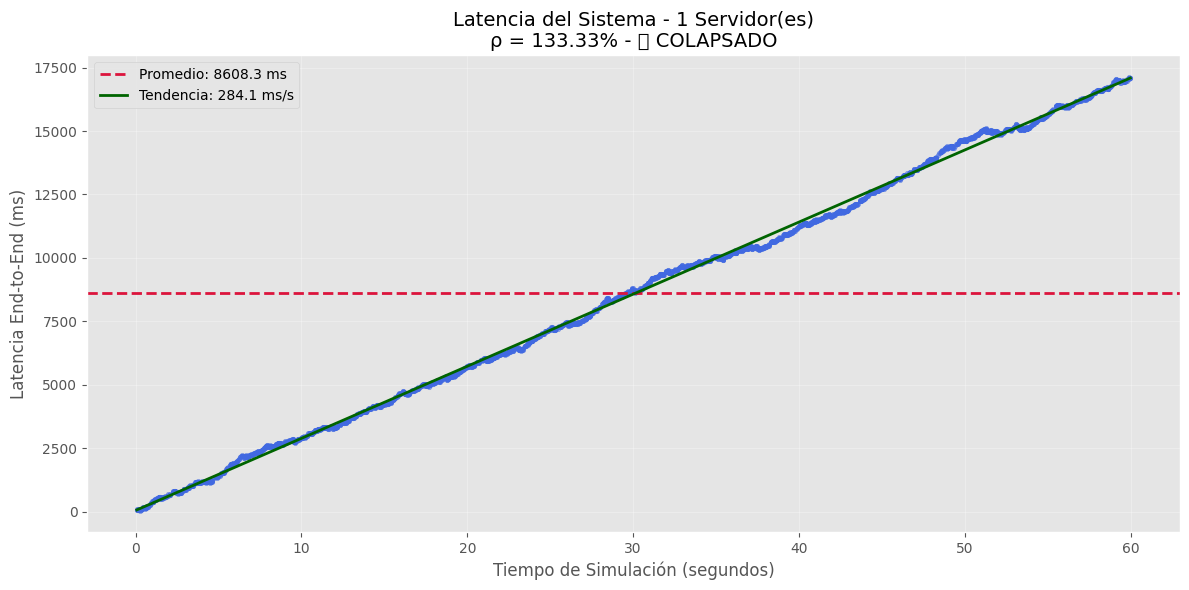


SIMULANDO CON 2 SERVIDOR(ES)

SISTEMA CON 2 SERVIDOR(ES)
Total de peticiones procesadas: 4805
Latencia promedio: 80.23 ms
Latencia máxima: 242.79 ms
Desviación estándar latencia: 29.29 ms
Percentil 95: 137.99 ms
Percentil 99: 173.20 ms
Tiempo de espera promedio en cola: 13.42 ms
Tiempo máximo de espera en cola: 175.84 ms
Factor de Utilización (ρ): 66.67%
Peticiones promedio en sistema (Ley de Little): 6.42
Estado del sistema: 🟢 ESTABLE - Buen rendimiento



/tmp/ipykernel_1401/229988388.py:51: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


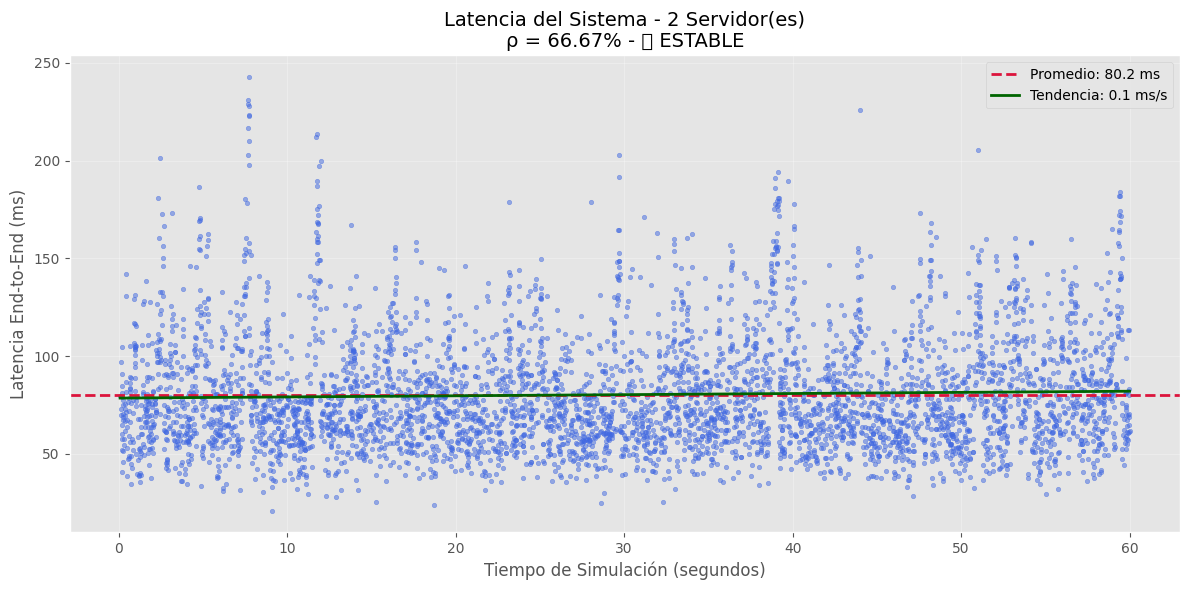


SIMULANDO CON 3 SERVIDOR(ES)

SISTEMA CON 3 SERVIDOR(ES)
Total de peticiones procesadas: 4778
Latencia promedio: 68.77 ms
Latencia máxima: 201.27 ms
Desviación estándar latencia: 20.22 ms
Percentil 95: 106.33 ms
Percentil 99: 129.92 ms
Tiempo de espera promedio en cola: 1.82 ms
Tiempo máximo de espera en cola: 66.91 ms
Factor de Utilización (ρ): 44.44%
Peticiones promedio en sistema (Ley de Little): 5.50
Estado del sistema: 🔵 INFRUTILIZADO - Capacidad excedente



/tmp/ipykernel_1401/229988388.py:51: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


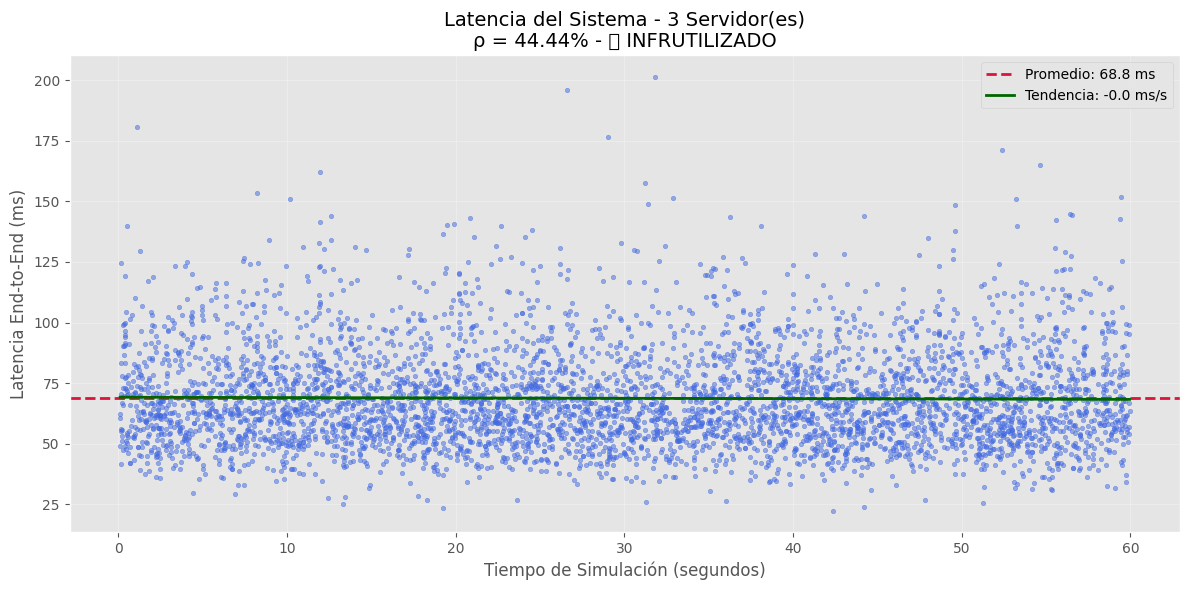


SIMULANDO CON 4 SERVIDOR(ES)

SISTEMA CON 4 SERVIDOR(ES)
Total de peticiones procesadas: 4899
Latencia promedio: 66.90 ms
Latencia máxima: 182.31 ms
Desviación estándar latencia: 19.37 ms
Percentil 95: 103.26 ms
Percentil 99: 129.07 ms
Tiempo de espera promedio en cola: 0.30 ms
Tiempo máximo de espera en cola: 34.39 ms
Factor de Utilización (ρ): 33.33%
Peticiones promedio en sistema (Ley de Little): 5.35
Estado del sistema: 🔵 INFRUTILIZADO - Capacidad excedente



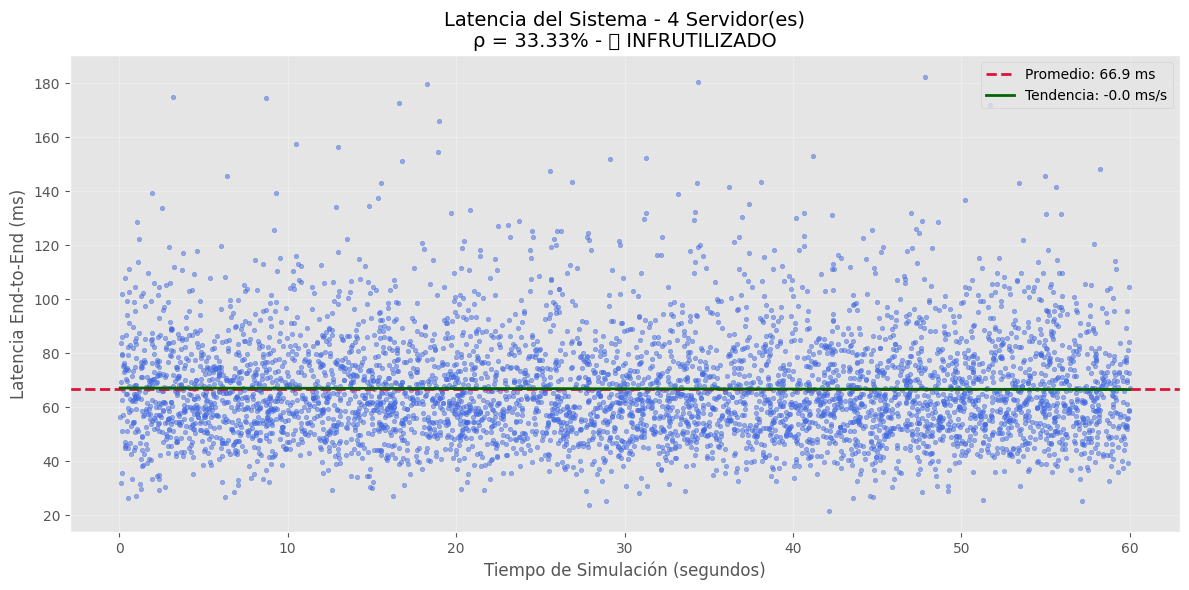

In [17]:
# ============================================
# Ejecuto la simulación para diferentes números de servidores:
# 1, 2, 3 y 4 servidores.
# Esto me permitirá observar el impacto del escalamiento
# horizontal en la latencia y estabilidad del sistema.
# Almaceno los resultados en un diccionario para
# análisis posterior y generación de gráficos comparativos.
# ============================================

print("\n" + "="*60)
print("INICIANDO SIMULACIONES DEL SISTEMA ACADÉMICO")
print("="*60)

# Diccionario para almacenar resultados
resultados = {}
configuraciones = [1, 2, 3, 4]

for n in configuraciones:
    print(f"\n{'='*60}")
    print(f"SIMULANDO CON {n} SERVIDOR(ES)")
    print(f"{'='*60}")

    sistema = simular_sistema(n)
    metricas = calcular_metricas(sistema, n)
    plt_obj = graficar_resultados(sistema, n)

    resultados[n] = {
        'sistema': sistema,
        'metricas': metricas,
        'plt': plt_obj
    }

    # Muestro el gráfico individual
    plt_obj.show()

**Gráfico Comparativo de Todos los Escenarios**

/tmp/ipykernel_1401/3731667203.py:69: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1401/3731667203.py:69: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1401/3731667203.py:69: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


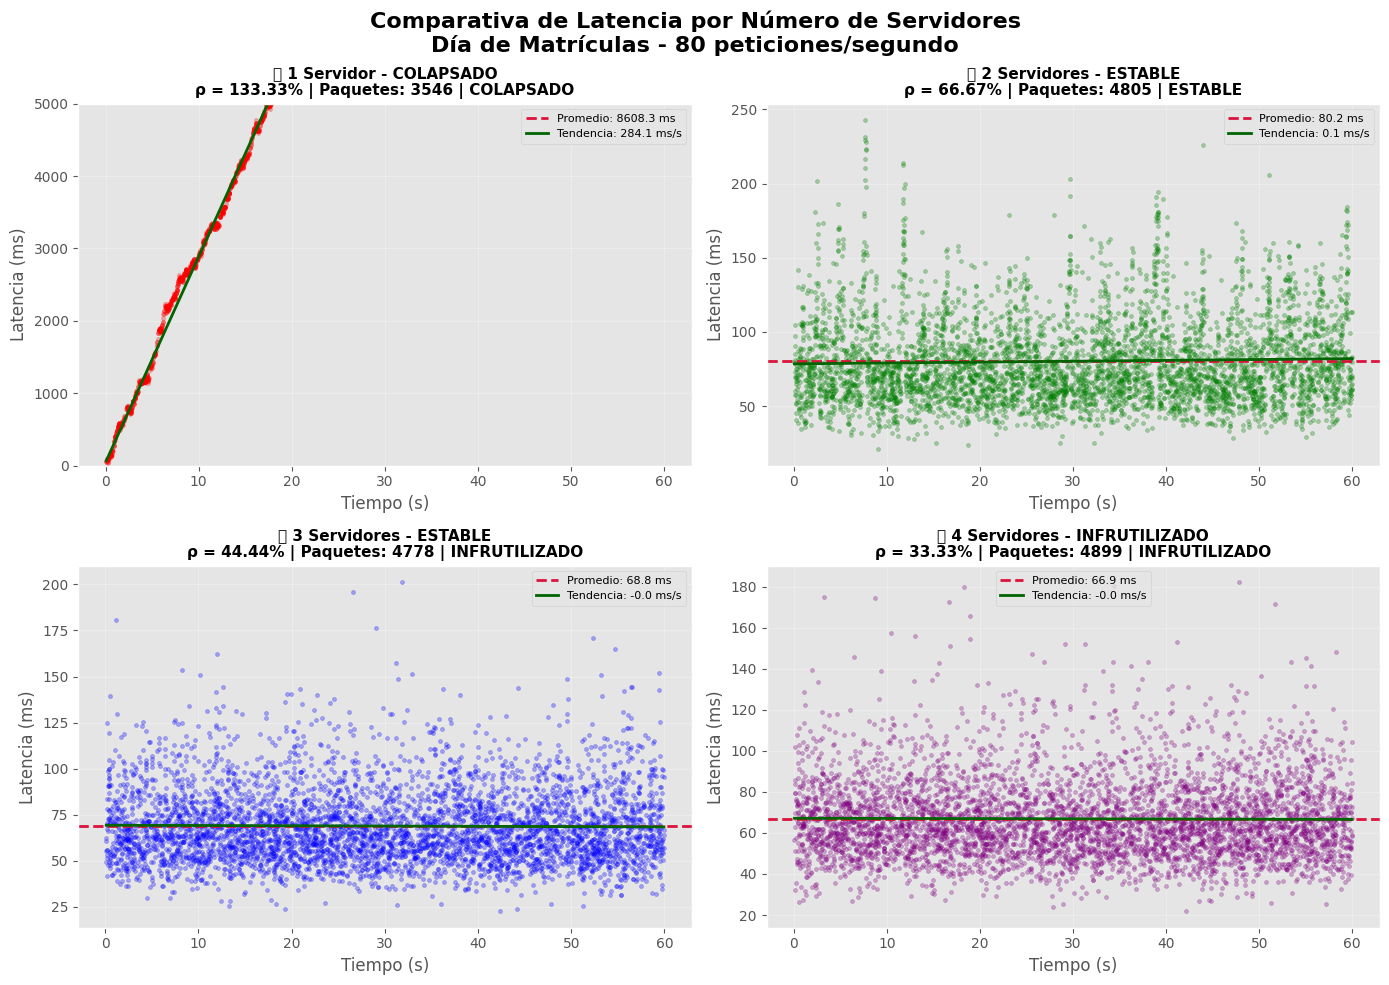

In [18]:
# ============================================
# Genero una vista comparativa con subplots para cada configuración.
# Esto permite visualizar fácilmente la evolución de la latencia
# a medida que se incrementa el número de servidores.
# La tendencia ascendente en el caso de 1 servidor evidencia
# el colapso del sistema, mientras que con 2 o más servidores
# la latencia se estabiliza.
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
configs = [
    (1, '1 Servidor - COLAPSADO', 'red', '🔴'),
    (2, '2 Servidores - ESTABLE', 'green', '🟢'),
    (3, '3 Servidores - ESTABLE', 'blue', '🟢'),
    (4, '4 Servidores - INFRUTILIZADO', 'purple', '🔵')
]

for idx, (n, title, color, emoji) in enumerate(configs):
    row, col = idx // 2, idx % 2
    ax = axes[row, col]

    sistema = resultados[n]['sistema']
    tiempos_ms = [t * 1000 for t in sistema.tiempos_respuesta_total]

    # Gráfico de dispersión
    ax.scatter(sistema.marcas_tiempo, tiempos_ms, alpha=0.3, s=8, color=color)

    # Línea de promedio
    media = np.mean(tiempos_ms)
    ax.axhline(y=media, color='crimson', linestyle='--',
               linewidth=2, label=f'Promedio: {media:.1f} ms')

    # Línea de tendencia
    if len(sistema.marcas_tiempo) > 1:
        z = np.polyfit(sistema.marcas_tiempo, tiempos_ms, 1)
        p = np.poly1d(z)
        x_trend = np.linspace(min(sistema.marcas_tiempo), max(sistema.marcas_tiempo), 100)
        ax.plot(x_trend, p(x_trend), color='darkgreen', linewidth=2,
                label=f'Tendencia: {z[0]:.1f} ms/s')

    # Información del sistema
    rho = TASA_LLEGADA_DATOS / (CAPACIDAD_PROCESAMIENTO * n)
    paquetes = len(tiempos_ms)

    if rho > 1:
        estado = "COLAPSADO"
    elif rho > 0.8:
        estado = "SOBRECARGADO"
    elif rho > 0.5:
        estado = "ESTABLE"
    else:
        estado = "INFRUTILIZADO"

    ax.set_title(f'{emoji} {title}\n' +
                 f'ρ = {rho:.2%} | Paquetes: {paquetes} | {estado}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Tiempo (s)')
    ax.set_ylabel('Latencia (ms)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # Ajustar límites para mejor visualización
    if n == 1:
        ax.set_ylim(0, min(5000, max(tiempos_ms) * 1.1))

plt.suptitle('Comparativa de Latencia por Número de Servidores\n' +
             'Día de Matrículas - 80 peticiones/segundo',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

**Tabla Resumen de Resultados con Estados**

In [19]:
# ============================================
# Presento una tabla comparativa con todas las métricas clave
# para cada configuración de servidores.
# Incluyo los emojis de estado para identificar rápidamente
# la condición de cada sistema.
# Esto facilita la comparación directa y la identificación
# del punto óptimo de escalamiento (2 servidores).
# ============================================

print("\n" + "="*100)
print("RESUMEN COMPARATIVO DE SIMULACIONES")
print("="*100)

# Definir los emojis según el estado
def obtener_estado_emoji(rho):
    if rho > 1:
        return "🔴 COLAPSADO"
    elif rho > 0.8:
        return "🟡 SOBRECARGADO"
    elif rho > 0.5:
        return "🟢 ESTABLE"
    else:
        return "🔵 INFRUTILIZADO"

print(f"\n{'Servidores':<12} {'Peticiones':<12} {'Latencia Media (ms)':<22} {'Espera (ms)':<18} {'ρ (%)':<12} {'Estado':<20}")
print("-"*100)

for n in [1, 2, 3, 4]:
    sistema = resultados[n]['sistema']
    lat_media = np.mean(sistema.tiempos_respuesta_total) * 1000
    esp_media = np.mean(sistema.tiempos_espera_cola) * 1000
    rho = TASA_LLEGADA_DATOS / (CAPACIDAD_PROCESAMIENTO * n)

    estado = obtener_estado_emoji(rho)

    print(f"{n:<12} {len(sistema.tiempos_respuesta_total):<12} {lat_media:<22.1f} {esp_media:<18.1f} {rho*100:<12.1f} {estado:<20}")

print("\n" + "="*100)


RESUMEN COMPARATIVO DE SIMULACIONES

Servidores   Peticiones   Latencia Media (ms)    Espera (ms)        ρ (%)        Estado              
----------------------------------------------------------------------------------------------------
1            3546         8608.3                 8543.9             133.3        🔴 COLAPSADO         
2            4805         80.2                   13.4               66.7         🟢 ESTABLE           
3            4778         68.8                   1.8                44.4         🔵 INFRUTILIZADO     
4            4899         66.9                   0.3                33.3         🔵 INFRUTILIZADO     



**Justificación Matemática del Escalamiento**

In [20]:
# ============================================
# La Teoría de Colas nos proporciona el marco teórico
# para justificar por qué 2 servidores son suficientes.
# El factor de utilización (ρ) es la métrica clave:
#
# ρ = λ / (N × μ)
#
# Donde:
# - λ = Tasa de llegada (80 peticiones/segundo)
# - μ = Capacidad por servidor (60 peticiones/segundo)
# - N = Número de servidores
#
# Para que el sistema sea estable, necesitamos ρ < 1.
# Con 1 servidor: ρ = 80/60 = 1.33 > 1 (INESTABLE)
# Con 2 servidores: ρ = 80/120 = 0.67 < 1 (ESTABLE)
#
# Por lo tanto, 2 servidores es la solución exacta que
# transforma un sistema inestable en estable.
# ============================================

print("\n" + "="*60)
print("JUSTIFICACIÓN MATEMÁTICA DEL ESCALAMIENTO")
print("="*60)

print("""
FACTOR DE UTILIZACIÓN: ρ = λ / (N × μ)

Donde:
  λ = Tasa de llegada = 80 peticiones/segundo
  μ = Capacidad por servidor = 60 peticiones/segundo
  N = Número de servidores

RESULTADOS:

  1 servidor:  ρ = 80/(1 × 60) = 1.3333 = 133.33%  → 🔴 INESTABLE
               La cola crece infinitamente (ρ > 1)

  2 servidores: ρ = 80/(2 × 60) = 0.6667 = 66.67%   → 🟢 ESTABLE
                El sistema alcanza estado estacionario (ρ < 1)

  3 servidores: ρ = 80/(3 × 60) = 0.4444 = 44.44%   → 🟢 ESTABLE
                Capacidad excedente (sobredimensionado)

  4 servidores: ρ = 80/(4 × 60) = 0.3333 = 33.33%   → 🔵 INFRUTILIZADO
                Recursos infrautilizados

CONCLUSIÓN: 2 servidores es la solución óptima porque:

  1. Logra ρ < 1, garantizando estabilidad del sistema
  2. Proporciona un margen de seguridad del 33.33%
  3. Evita el sobredimensionamiento (3-4 servidores)
  4. Minimiza costos operativos

VERIFICACIÓN CON LEY DE LITTLE:
  L = λ × W
  - Con 1 servidor: L tiende a infinito (sistema inestable)
  - Con 2 servidores: L = 80 × W_estable (sistema en equilibrio)
""")

print("="*60)


JUSTIFICACIÓN MATEMÁTICA DEL ESCALAMIENTO

FACTOR DE UTILIZACIÓN: ρ = λ / (N × μ)

Donde:
  λ = Tasa de llegada = 80 peticiones/segundo
  μ = Capacidad por servidor = 60 peticiones/segundo
  N = Número de servidores

RESULTADOS:

  1 servidor:  ρ = 80/(1 × 60) = 1.3333 = 133.33%  → 🔴 INESTABLE
               La cola crece infinitamente (ρ > 1)

  2 servidores: ρ = 80/(2 × 60) = 0.6667 = 66.67%   → 🟢 ESTABLE
                El sistema alcanza estado estacionario (ρ < 1)

  3 servidores: ρ = 80/(3 × 60) = 0.4444 = 44.44%   → 🟢 ESTABLE
                Capacidad excedente (sobredimensionado)

  4 servidores: ρ = 80/(4 × 60) = 0.3333 = 33.33%   → 🔵 INFRUTILIZADO
                Recursos infrautilizados

CONCLUSIÓN: 2 servidores es la solución óptima porque:

  1. Logra ρ < 1, garantizando estabilidad del sistema
  2. Proporciona un margen de seguridad del 33.33%
  3. Evita el sobredimensionamiento (3-4 servidores)
  4. Minimiza costos operativos

VERIFICACIÓN CON LEY DE LITTLE:
  L = λ × W

**Gráfico de Barras Comparativo**

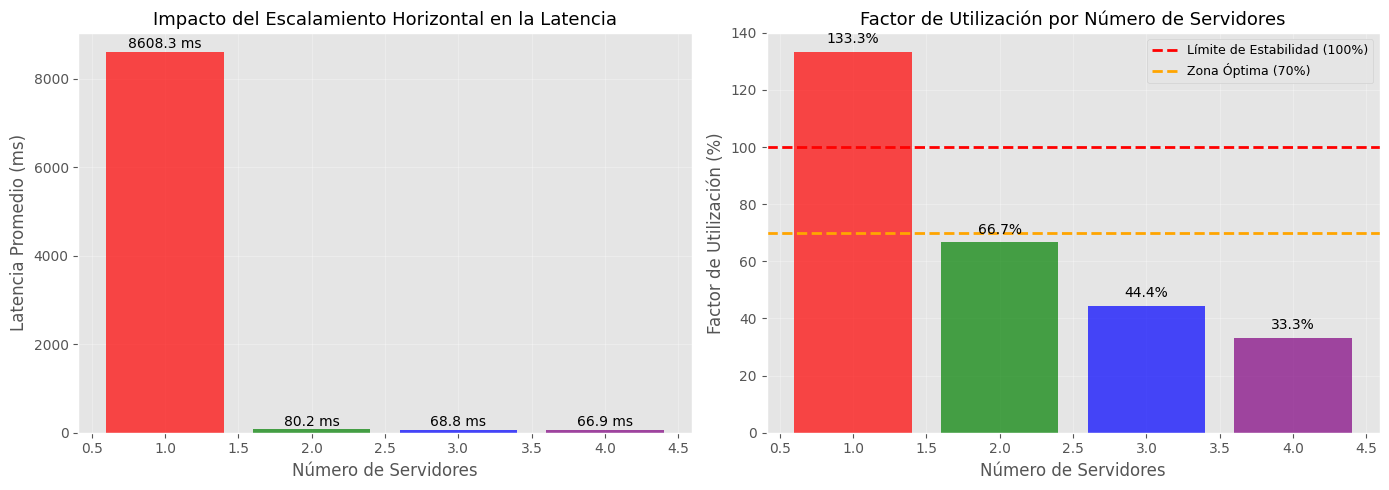

In [21]:
# ============================================
# Genero gráficos de barras para visualizar:
# 1. Latencia promedio por número de servidores
# 2. Factor de utilización por número de servidores
# Esto complementa el análisis visual y facilita
# la identificación del punto de inflexión en 2 servidores.
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Latencia por número de servidores
ax1 = axes[0]
servidores = [1, 2, 3, 4]
latencias = [np.mean(resultados[n]['sistema'].tiempos_respuesta_total) * 1000 for n in servidores]
colores = ['red', 'green', 'blue', 'purple']

bars1 = ax1.bar(servidores, latencias, color=colores, alpha=0.7)
ax1.set_xlabel('Número de Servidores', fontsize=12)
ax1.set_ylabel('Latencia Promedio (ms)', fontsize=12)
ax1.set_title('Impacto del Escalamiento Horizontal en la Latencia', fontsize=13)

# Agregar valores en las barras
for bar, lat in zip(bars1, latencias):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f'{lat:.1f} ms', ha='center', va='bottom', fontsize=10)

ax1.grid(True, alpha=0.3)

# Gráfico 2: Factor de utilización
ax2 = axes[1]
utilizaciones = [TASA_LLEGADA_DATOS / (CAPACIDAD_PROCESAMIENTO * n) * 100 for n in servidores]

bars2 = ax2.bar(servidores, utilizaciones, color=colores, alpha=0.7)
ax2.set_xlabel('Número de Servidores', fontsize=12)
ax2.set_ylabel('Factor de Utilización (%)', fontsize=12)
ax2.set_title('Factor de Utilización por Número de Servidores', fontsize=13)

# Agregar valores en las barras
for bar, util in zip(bars2, utilizaciones):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'{util:.1f}%', ha='center', va='bottom', fontsize=10)

# Línea de referencia para 100%
ax2.axhline(y=100, color='red', linestyle='--', linewidth=2,
            label='Límite de Estabilidad (100%)')
ax2.axhline(y=70, color='orange', linestyle='--', linewidth=2,
            label='Zona Óptima (70%)')
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Análisis de Estabilidad con Ley de Little**

In [22]:
# ============================================
# La Ley de Little (L = λ × W) nos permite verificar
# la estabilidad del sistema desde otra perspectiva.
# Para un sistema estable, el número promedio de peticiones
# en el sistema (L) debe ser finito y constante en el tiempo.
# Con 1 servidor (ρ > 1), L tiende a infinito.
# Con 2 servidores (ρ < 1), L alcanza un valor finito.
# ============================================

print("\n" + "="*60)
print("ANÁLISIS DE ESTABILIDAD CON LEY DE LITTLE")
print("="*60)

def obtener_estado_emoji(rho):
    if rho > 1:
        return "🔴 INESTABLE"
    elif rho > 0.8:
        return "🟡 SOBRECARGADO"
    elif rho > 0.5:
        return "🟢 ESTABLE"
    else:
        return "🔵 INFRUTILIZADO"

for n in [1, 2, 3, 4]:
    sistema = resultados[n]['sistema']
    rho = TASA_LLEGADA_DATOS / (CAPACIDAD_PROCESAMIENTO * n)

    # Tiempo promedio en el sistema (W)
    W = np.mean(sistema.tiempos_respuesta_total)

    # Número promedio de peticiones en el sistema (L = λ × W)
    L = TASA_LLEGADA_DATOS * W

    estado = obtener_estado_emoji(rho)

    print(f"\n{estado} - {n} Servidor(es):")
    print(f"  • Factor de Utilización (ρ): {rho:.2%}")
    print(f"  • Tiempo promedio en sistema (W): {W*1000:.2f} ms")
    print(f"  • Peticiones promedio en sistema (L = λW): {L:.2f}")

    if rho > 1:
        print(f"  • ⚠️ SISTEMA INESTABLE - ρ > 1")
        print(f"  • ⚠️ La cola crece indefinidamente")
        print(f"  • ⚠️ L tiende a infinito")
    else:
        print(f"  • ✅ SISTEMA ESTABLE")
        print(f"  • ✅ L es finito: {L:.2f} peticiones")

        # Margen de seguridad
        margen = (1 - rho) * 100
        print(f"  • ✅ Margen de seguridad: {margen:.1f}%")

print("\n" + "="*60)


ANÁLISIS DE ESTABILIDAD CON LEY DE LITTLE

🔴 INESTABLE - 1 Servidor(es):
  • Factor de Utilización (ρ): 133.33%
  • Tiempo promedio en sistema (W): 8608.32 ms
  • Peticiones promedio en sistema (L = λW): 688.67
  • ⚠️ SISTEMA INESTABLE - ρ > 1
  • ⚠️ La cola crece indefinidamente
  • ⚠️ L tiende a infinito

🟢 ESTABLE - 2 Servidor(es):
  • Factor de Utilización (ρ): 66.67%
  • Tiempo promedio en sistema (W): 80.23 ms
  • Peticiones promedio en sistema (L = λW): 6.42
  • ✅ SISTEMA ESTABLE
  • ✅ L es finito: 6.42 peticiones
  • ✅ Margen de seguridad: 33.3%

🔵 INFRUTILIZADO - 3 Servidor(es):
  • Factor de Utilización (ρ): 44.44%
  • Tiempo promedio en sistema (W): 68.77 ms
  • Peticiones promedio en sistema (L = λW): 5.50
  • ✅ SISTEMA ESTABLE
  • ✅ L es finito: 5.50 peticiones
  • ✅ Margen de seguridad: 55.6%

🔵 INFRUTILIZADO - 4 Servidor(es):
  • Factor de Utilización (ρ): 33.33%
  • Tiempo promedio en sistema (W): 66.90 ms
  • Peticiones promedio en sistema (L = λW): 5.35
  • ✅ SISTEMA